# **Machine learning - Smart Inventory Demand Prediction**

This dataset records daily product sales information along with **pricing**, **promotions**, and **external factors**.

It includes variables like **discounts**, **weather**, **festivals**, **competitor pricing**, and **marketing spend**. The **target variable demand** represents the quantity sold for each product.

###Smart inventory dataset description:
1. **date** — The day the observation or sales record was captured.
2. **product_id** — Unique identifier for each product.
3. **base_price** — Original price of the product before discounts.
4. **discount** — Percentage or amount reduced from the base price.
5. **weather** — Weather condition on that date (e.g., sunny, rainy).
6. **temperature** — Recorded temperature for the day.
7. **festival** — Indicates whether a festival/holiday occurred (yes/no or name).
8. **competitor_price** — Price of the same/similar product offered by competitors.
9. **marketing_spend** — Amount spent on promotions/advertising.
10. **demand** — Quantity of product requested or sold.

###**Steps of Machine Learning**
1. Problem Statement
2. Data Collection
3. Data PreProcessing
4. EDA
5. Feature Enginering
6. Model Traning
7. Model Selection
8. Model Evluation
9. Model Deployment
10. Maintainance / Update

##**Importing Libraries**

In [312]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##**Loading Dataset**

In [313]:
df_smart_inv = pd.read_csv("/content/smart_inventory_dataset.csv")

In [314]:
df_smart_inv.head()

,date,product_id,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand
0,01-01-2023,1006,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38
1,02-01-2023,1003,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31
2,03-01-2023,1007,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21
3,04-01-2023,1004,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84
4,05-01-2023,1006,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64


## **Data PreProcessing**
1. Check the dataset structure, columns, and basic statistics; identify missing values.

2. Handle missing data, transform data types, and manage outliers.

In [315]:
# columns description
df_smart_inv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              1000 non-null   object 
 1   product_id        1000 non-null   int64  
 2   base_price        1000 non-null   float64
 3   discount          1000 non-null   float64
 4   weather           1000 non-null   object 
 5   temperature       1000 non-null   float64
 6   festival          1000 non-null   int64  
 7   competitor_price  1000 non-null   float64
 8   marketing_spend   1000 non-null   float64
 9   demand            1000 non-null   int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 78.3+ KB


In [316]:
# dataframe shape (rows and columns)
df_smart_inv.shape

(1000, 10)

In [317]:
# dataframe columns name
df_smart_inv.columns

Index(['date', 'product_id', 'base_price', 'discount', 'weather',
       'temperature', 'festival', 'competitor_price', 'marketing_spend',
       'demand'],
      dtype='object')

In [318]:
# finding null values and aggregate of null values
df_smart_inv.isnull().sum()

,0
date,0
product_id,0
base_price,0
discount,0
weather,0
temperature,0
festival,0
competitor_price,0
marketing_spend,0
demand,0


In [319]:
# reset date column, then convert with the explicit format
df_smart_inv["date"] = pd.to_datetime(df_smart_inv["date"], dayfirst=True)

In [320]:
df_smart_inv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1000 non-null   datetime64[ns]
 1   product_id        1000 non-null   int64         
 2   base_price        1000 non-null   float64       
 3   discount          1000 non-null   float64       
 4   weather           1000 non-null   object        
 5   temperature       1000 non-null   float64       
 6   festival          1000 non-null   int64         
 7   competitor_price  1000 non-null   float64       
 8   marketing_spend   1000 non-null   float64       
 9   demand            1000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(3), object(1)
memory usage: 78.3+ KB


In [321]:
# remove unwanted column which not affect in prediction
df_smart_inv = df_smart_inv.drop("product_id", axis = 1)

In [322]:
df_smart_inv

,date,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand
0,2023-01-01,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38
1,2023-01-02,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31
2,2023-01-03,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21
3,2023-01-04,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84
4,2023-01-05,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64
...,...,...,...,...,...,...,...,...,...
995,2025-09-22,280.25,0.15,Rainy,22.0,1,102.67,6802.81,72
996,2025-09-23,452.98,0.12,Rainy,22.3,0,322.16,4056.95,10
997,2025-09-24,142.28,0.29,Sunny,39.3,0,300.29,7371.53,61
998,2025-09-25,495.31,0.16,Rainy,15.4,0,467.84,6016.82,25


In [323]:
# statistics description of numeric columns
df_smart_inv.describe()

,date,base_price,discount,temperature,festival,competitor_price,marketing_spend,demand
count,1000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,2024-05-14 12:00:00,301.079240,0.15098,24.572600,0.202000,284.158920,5396.36015,48.249000
min,2023-01-01 00:00:00,100.100000,0.00000,10.000000,0.000000,91.530000,1002.17000,0.000000
25%,2023-09-07 18:00:00,201.657500,0.07000,17.000000,0.000000,185.317500,3139.76500,34.000000
50%,2024-05-14 12:00:00,306.070000,0.16000,24.400000,0.000000,284.920000,5337.52500,48.000000
75%,2025-01-19 06:00:00,399.277500,0.23000,31.900000,0.000000,380.720000,7702.13000,61.000000
max,2025-09-26 00:00:00,499.740000,0.30000,40.000000,1.000000,479.790000,9992.87000,117.000000
std,NaN,113.657034,0.08766,8.614477,0.401693,112.719403,2596.60294,20.307176


## **EDA - Exploratary Data Analysis**
Analyze summary statistics, correlations, and identify trends or issues.

In [324]:
corr = df_smart_inv.corr(numeric_only = True )

<Axes: >

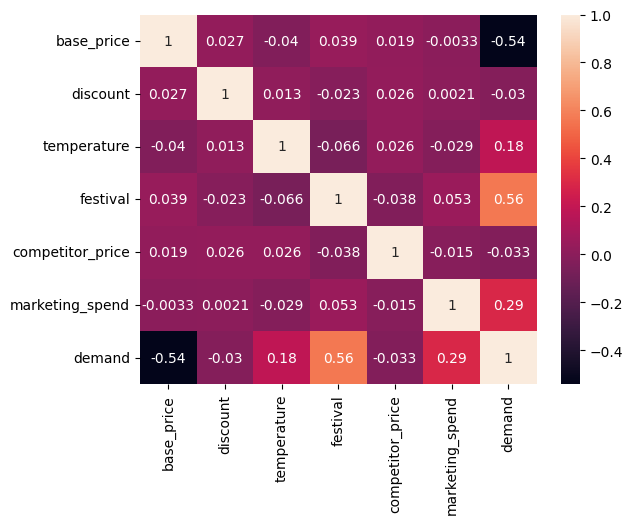

In [325]:
sns.heatmap(corr, annot = True)

In [326]:
df_col = df_smart_inv[['base_price', 'discount',
                      'temperature', 'marketing_spend']]

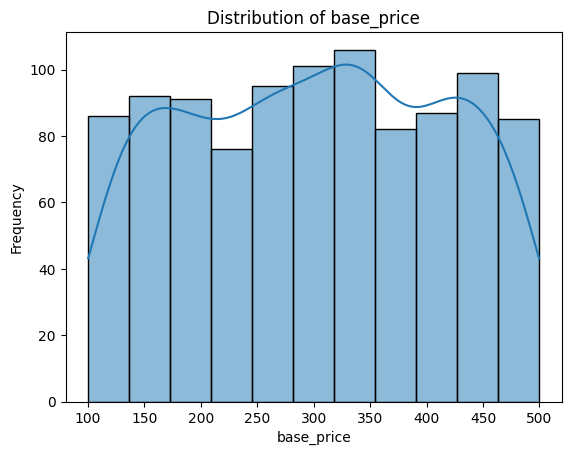

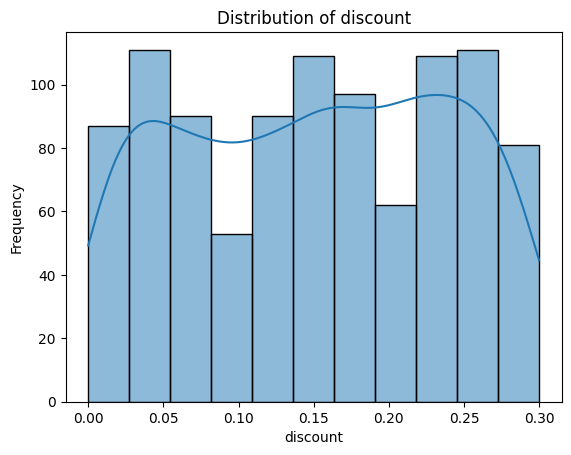

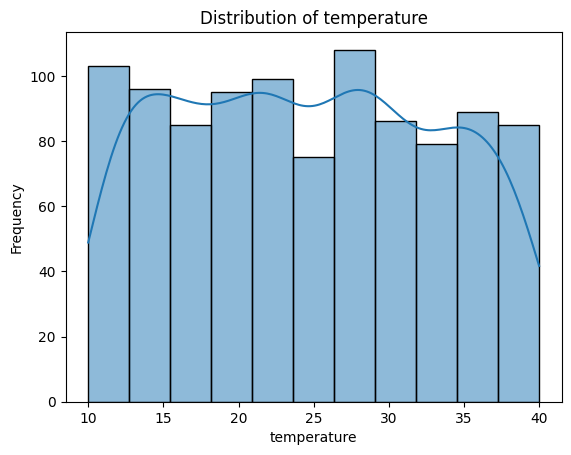

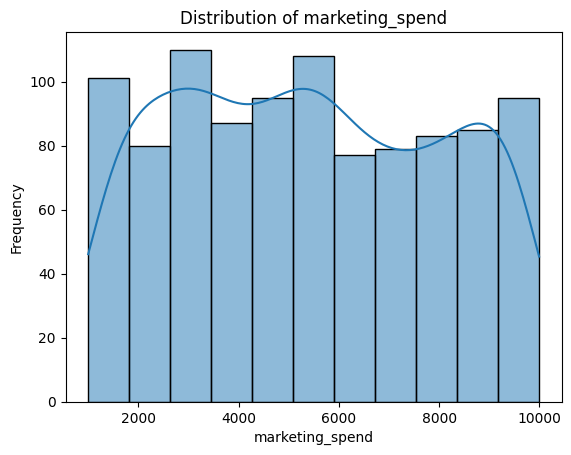

In [327]:
for col in df_col:
  sns.histplot(df_smart_inv[col], kde = True)

  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

**Insight:**
1. Distribution of Base Price — Base prices are evenly spread, indicating a diverse product pricing strategy.

2. Distribution of Discount — Discounts are mostly concentrated at lower percentages with fewer high-discount offers.

3. Distribution of Marketing Spend — Marketing budgets cluster around mid-range values with occasional high spending.

4. Distribution of Temperature — Temperature values are uniformly distributed, representing different seasonal conditions.

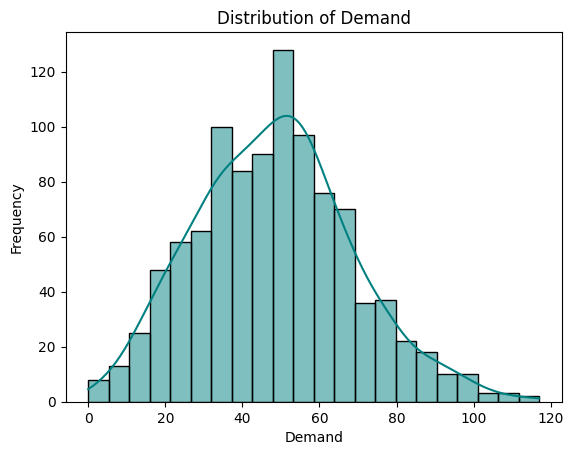

In [328]:
# Plotting histplot
sns.histplot(df_smart_inv["demand"], color = "teal", kde = True)

plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

**Insight:**

1. Demand follows a **near normal distribution** centered around **50–60 units**.
2. Most **sales** occur **between 30 and 70 demand range**, indicating stable demand levels.
3. **Very low (<10) and very high (>100) demand** values are rare outliers.
4. **Slight right skew** suggests occasional **high-demand spikes**.
5. **Bell-shaped curve** indicates good data for regression-based ML models.

In [329]:
df_smart_inv['discount_percent'] = (df_smart_inv['discount'] * 100).astype(int)

In [330]:
df_smart_inv.head()

,date,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand,discount_percent
0,2023-01-01,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38,1
1,2023-01-02,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31,1
2,2023-01-03,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21,22
3,2023-01-04,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84,20
4,2023-01-05,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64,24


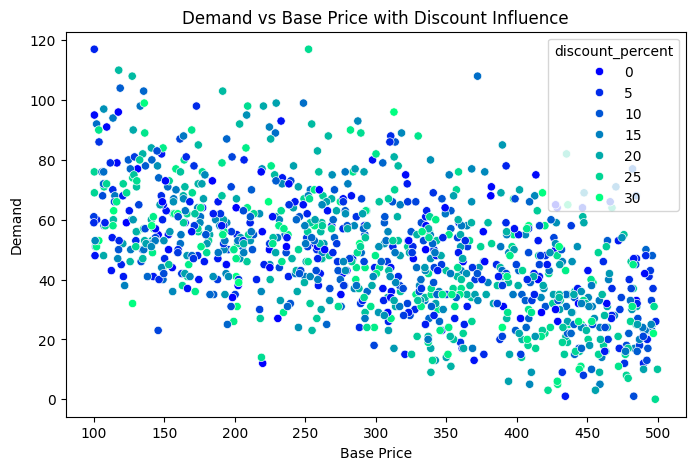

In [331]:
# Plotting scatterplot - relationship between base price and demand
plt.figure(figsize=(8,5))

sns.scatterplot(data=df_smart_inv, x='base_price', y='demand', hue='discount_percent', palette = "winter")

plt.title('Demand vs Base Price with Discount Influence')
plt.xlabel('Base Price')
plt.ylabel('Demand')
plt.grid(False)
plt.show()

**Insights:**
1. **10–20% discount** noticeably **increases demand** at **higher price ranges**.
2. **Products priced** below **mid-range** show consistently **higher demand**.
3. **Higher discounts** cluster around **higher demand** points, indicating promotional impact.
4. **Without discounts**, **high base price products** show significantly **lower demand**.

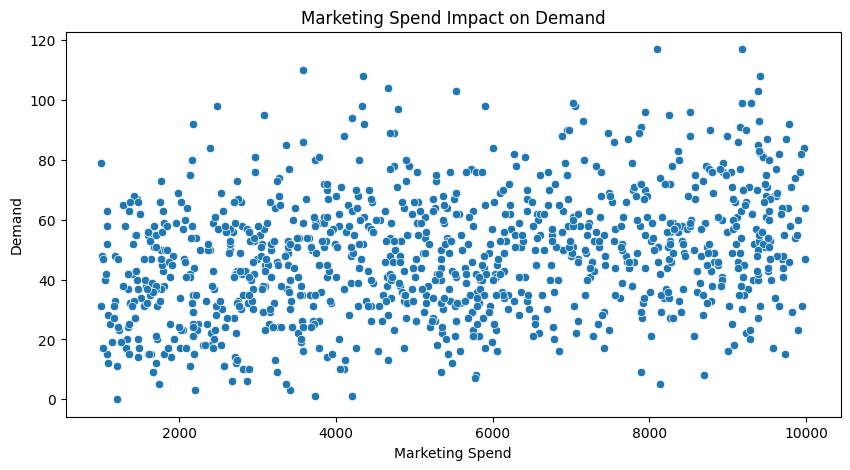

In [332]:
# Plotting regplot - positive correlation between marketing spend and demand
plt.figure(figsize=(10,5))
sns.scatterplot(data=df_smart_inv, x='marketing_spend', y='demand')

plt.title('Marketing Spend Impact on Demand')
plt.xlabel('Marketing Spend')
plt.ylabel('Demand')
plt.show()

**Insights:**
1. **Demand rises** steadily as **marketing spend increases**.
2. **Low marketing spend** levels correspond to **lower demand** clusters.
3. **Mid-level marketing budgets** show the most **efficient demand growth**.
4. **Very high marketing spend** produces diminishing but still **positive returns**.

In [333]:
df_smart_inv["year"] = df_smart_inv["date"].dt.year
df_smart_inv["month"] = df_smart_inv["date"].dt.month

In [334]:
df_smart_inv

,date,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand,discount_percent,year,month
0,2023-01-01,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38,1,2023,1
1,2023-01-02,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31,1,2023,1
2,2023-01-03,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21,22,2023,1
3,2023-01-04,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84,20,2023,1
4,2023-01-05,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64,24,2023,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2025-09-22,280.25,0.15,Rainy,22.0,1,102.67,6802.81,72,15,2025,9
996,2025-09-23,452.98,0.12,Rainy,22.3,0,322.16,4056.95,10,12,2025,9
997,2025-09-24,142.28,0.29,Sunny,39.3,0,300.29,7371.53,61,28,2025,9
998,2025-09-25,495.31,0.16,Rainy,15.4,0,467.84,6016.82,25,16,2025,9


##**Feature Creation**

Generating new variables from existing ones to highlight specific patterns.

Example: BMI = 27

Create New Column -> BMI Category = underweight, normal, overweight, obese

In [335]:
df_smart_inv["is_temp"] = pd.cut(df_smart_inv["temperature"],
                          bins = [-float("inf"), 20 , 30, float("inf")],
                          labels = ["cold", "warm", "hot"]
                          )

In [336]:
df_smart_inv.head(10)

,date,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand,discount_percent,year,month,is_temp
0,2023-01-01,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38,1,2023,1,warm
1,2023-01-02,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31,1,2023,1,cold
2,2023-01-03,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21,22,2023,1,warm
3,2023-01-04,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84,20,2023,1,hot
4,2023-01-05,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64,24,2023,1,hot
5,2023-01-06,416.03,0.03,Cloudy,21.2,1,250.35,3882.69,41,3,2023,1,warm
6,2023-01-07,109.21,0.01,Rainy,38.3,1,364.57,9159.88,91,1,2023,1,hot
7,2023-01-08,360.55,0.15,Rainy,15.0,0,174.81,2721.18,43,15,2023,1,cold
8,2023-01-09,408.50,0.12,Rainy,25.0,0,233.00,6538.86,27,12,2023,1,warm
9,2023-01-10,249.77,0.14,Rainy,30.7,0,242.46,4651.43,41,14,2023,1,hot


In [337]:
# final price
df_smart_inv["final_price"] = df_smart_inv["base_price"] * (1 - df_smart_inv["discount"])

In [338]:
df_smart_inv.head()

,date,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand,discount_percent,year,month,is_temp,final_price
0,2023-01-01,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38,1,2023,1,warm,200.3859
1,2023-01-02,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31,1,2023,1,cold,386.5356
2,2023-01-03,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21,22,2023,1,warm,263.0082
3,2023-01-04,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84,20,2023,1,hot,112.7120
4,2023-01-05,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64,24,2023,1,hot,355.3000


In [339]:
df_smart_inv["is_comp_price"] = (df_smart_inv["base_price"] < df_smart_inv["competitor_price"]).astype(int)

In [340]:
df_smart_inv.head()

,date,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand,discount_percent,year,month,is_temp,final_price,is_comp_price
0,2023-01-01,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38,1,2023,1,warm,200.3859,1
1,2023-01-02,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31,1,2023,1,cold,386.5356,0
2,2023-01-03,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21,22,2023,1,warm,263.0082,0
3,2023-01-04,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84,20,2023,1,hot,112.7120,1
4,2023-01-05,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64,24,2023,1,hot,355.3000,0


In [341]:
df_smart_inv["festival_impact"] = (df_smart_inv["festival"] * df_smart_inv["marketing_spend"])

In [342]:
df_smart_inv.head(10)

,date,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand,discount_percent,year,month,is_temp,final_price,is_comp_price,festival_impact
0,2023-01-01,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38,1,2023,1,warm,200.3859,1,0.00
1,2023-01-02,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31,1,2023,1,cold,386.5356,0,0.00
2,2023-01-03,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21,22,2023,1,warm,263.0082,0,0.00
3,2023-01-04,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84,20,2023,1,hot,112.7120,1,0.00
4,2023-01-05,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64,24,2023,1,hot,355.3000,0,4873.09
5,2023-01-06,416.03,0.03,Cloudy,21.2,1,250.35,3882.69,41,3,2023,1,warm,403.5491,0,3882.69
6,2023-01-07,109.21,0.01,Rainy,38.3,1,364.57,9159.88,91,1,2023,1,hot,108.1179,1,9159.88
7,2023-01-08,360.55,0.15,Rainy,15.0,0,174.81,2721.18,43,15,2023,1,cold,306.4675,0,0.00
8,2023-01-09,408.50,0.12,Rainy,25.0,0,233.00,6538.86,27,12,2023,1,warm,359.4800,0,0.00
9,2023-01-10,249.77,0.14,Rainy,30.7,0,242.46,4651.43,41,14,2023,1,hot,214.8022,0,0.00


In [343]:
# price ratio
df_smart_inv["price_ratio"] = df_smart_inv["base_price"] / df_smart_inv["competitor_price"]

In [344]:
# is_weekend
df_smart_inv["is_weekend"] = df_smart_inv["date"].dt.dayofweek.isin([5, 6]).astype(int)

In [345]:
df_smart_inv.head()

,date,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand,discount_percent,year,month,is_temp,final_price,is_comp_price,festival_impact,price_ratio,is_weekend
0,2023-01-01,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38,1,2023,1,warm,200.3859,1,0.00,0.669190,1
1,2023-01-02,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31,1,2023,1,cold,386.5356,0,0.00,2.808921,0
2,2023-01-03,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21,22,2023,1,warm,263.0082,0,0.00,1.661116,0
3,2023-01-04,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84,20,2023,1,hot,112.7120,1,0.00,0.769428,0
4,2023-01-05,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64,24,2023,1,hot,355.3000,0,4873.09,2.697946,0


# **Feature Engineering**

Feature Engineering is the process of transforming raw data into meaningful inputs that help your machine learning model make better predictions.

## **Feature Encoding**

Converting text-based data (like "male/female" or "smoker/non-smoker") into numbers so the mathematical equations.

###**1. One Hot Encoding**

1. Assign a unique number of catrgories.
2. When we usage have oder or priority(odinal data - has order).

   Eg: Gender = is_male , is_female

In [346]:
df_cleaned = df_smart_inv.copy()

In [347]:
df_cleaned = pd.get_dummies(df_smart_inv, columns=["weather", "is_temp"], drop_first=True)

In [348]:
df_cleaned.rename(columns = {"weather_Cloudy" : 'is_weather_Cloudy',"weather_Rainy" : 'is_weather_Rainy', "weather_Sunny" : 'is_weather_Sunny'}, inplace = True)

In [349]:
df_cleaned.head()

,date,base_price,discount,temperature,festival,competitor_price,marketing_spend,demand,discount_percent,year,month,final_price,is_comp_price,festival_impact,price_ratio,is_weekend,is_weather_Rainy,is_weather_Sunny,is_temp_warm,is_temp_hot
0,2023-01-01,202.41,0.01,27.8,0,302.47,1572.41,38,1,2023,1,200.3859,1,0.00,0.669190,1,False,True,True,False
1,2023-01-02,390.44,0.01,11.6,0,139.00,5965.19,31,1,2023,1,386.5356,0,0.00,2.808921,0,False,True,False,False
2,2023-01-03,337.19,0.22,23.6,0,202.99,8569.87,21,22,2023,1,263.0082,0,0.00,1.661116,0,True,False,True,False
3,2023-01-04,140.89,0.20,30.2,0,183.11,9971.64,84,20,2023,1,112.7120,1,0.00,0.769428,0,False,False,False,True
4,2023-01-05,467.50,0.24,30.3,1,173.28,4873.09,64,24,2023,1,355.3000,0,4873.09,2.697946,0,False,False,False,True


## **Feature Scaling**
Rescaling numerical features to a similar range (0 and 1) for better model learning.

In [350]:
col_to_scale = ["base_price", "price_ratio", "temperature", "marketing_spend", "final_price", "festival_impact"]

In [351]:
# Apply standardization
from sklearn.preprocessing import StandardScaler

scaler_s = StandardScaler()

df_cleaned[col_to_scale] = scaler_s.fit_transform(df_cleaned[col_to_scale])

In [352]:
df_cleaned.head()

,date,base_price,discount,temperature,festival,competitor_price,marketing_spend,demand,discount_percent,year,month,final_price,is_comp_price,festival_impact,price_ratio,is_weekend,is_weather_Rainy,is_weather_Sunny,is_temp_warm,is_temp_hot
0,2023-01-01,-0.868566,0.01,0.374836,0,302.47,-1.473411,38,1,2023,1,-0.549822,1,-0.448433,-0.741679,1,False,True,True,False
1,2023-01-02,0.786625,0.01,-1.506660,0,139.00,0.219177,31,1,2023,1,1.312088,0,-0.448433,1.824032,0,False,True,False,False
2,2023-01-03,0.317876,0.22,-0.112959,0,202.99,1.222789,21,22,2023,1,0.076540,0,-0.448433,0.447721,0,True,False,True,False
3,2023-01-04,-1.410114,0.20,0.653576,0,183.11,1.762907,84,20,2023,1,-1.426756,1,-0.448433,-0.621485,0,False,False,False,True
4,2023-01-05,1.464969,0.24,0.665190,1,173.28,-0.201622,64,24,2023,1,0.999662,0,1.459137,1.690964,0,False,False,False,True


In [353]:
df_cleaned.columns

Index(['date', 'base_price', 'discount', 'temperature', 'festival',
       'competitor_price', 'marketing_spend', 'demand', 'discount_percent',
       'year', 'month', 'final_price', 'is_comp_price', 'festival_impact',
       'price_ratio', 'is_weekend', 'is_weather_Rainy', 'is_weather_Sunny',
       'is_temp_warm', 'is_temp_hot'],
      dtype='object')

In [354]:
from scipy.stats import pearsonr

# list of all colums to chack againest the target
col_list = ['date', 'base_price', 'discount', 'temperature', 'festival',
       'marketing_spend', 'year', 'month',
       'final_price', 'is_comp_price', 'festival_impact', 'price_ratio',
       'is_weekend', 'is_weather_Rainy', 'is_weather_Sunny',
       'is_temp_warm', 'is_temp_hot']


correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned["demand"])[0]
    for feature in col_list
}

In [355]:
correlations_df = pd.DataFrame(list(correlations.items()), columns = ["feature", "correlation"])

correlations_df.sort_values(by = "correlation", ascending = False, inplace = True)

In [356]:
correlations_df

,feature,correlation
4,festival,0.561744
10,festival_impact,0.555534
5,marketing_spend,0.289452
9,is_comp_price,0.274166
3,temperature,0.183593
16,is_temp_hot,0.149664
14,is_weather_Sunny,0.038668
15,is_temp_warm,0.005887
6,year,-0.001440
12,is_weekend,-0.004908


In [357]:
# make final column
final_df = df_cleaned[
    ["demand", "festival", "final_price", "price_ratio",
     "festival_impact", "marketing_spend", "is_comp_price",
     "base_price", "temperature"]
]

In [358]:
final_df.head()

,demand,festival,final_price,price_ratio,festival_impact,marketing_spend,is_comp_price,base_price,temperature
0,38,0,-0.549822,-0.741679,-0.448433,-1.473411,1,-0.868566,0.374836
1,31,0,1.312088,1.824032,-0.448433,0.219177,0,0.786625,-1.506660
2,21,0,0.076540,0.447721,-0.448433,1.222789,0,0.317876,-0.112959
3,84,0,-1.426756,-0.621485,-0.448433,1.762907,1,-1.410114,0.653576
4,64,1,0.999662,1.690964,1.459137,-0.201622,0,1.464969,0.665190


In [359]:
final_df.shape

(1000, 9)

## **Model Traning**
Teaching the model using training data to learn patterns.

In [360]:
from sklearn.model_selection import train_test_split

In [361]:
X = final_df.drop("demand", axis = 1)
y = final_df["demand"]

In [362]:
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state= 42)

##**Model Selection**
Choosing the best algorithm based on performance.

##**Linear regression**
1. Linear regression is one of the most fundamental algorithms in machine learning and statistics.

2. It forms the backbone of more advanced models and is essential for understanding how learning systems optimize themselves using gradient-based methods.

In [363]:
from sklearn.linear_model import LinearRegression

In [364]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [365]:
y_pred = model.predict(X_test)

In [366]:
y_pred = y_pred.astype(int)

In [367]:
y_pred

array([42, 98, 58, 45, 68, 53, 91, 35, 47, 56, 72, 50, 38, 46, 35, 31, 30,
       51, 31, 28, 31, 34, 65, 42, 32, 35, 56, 11, 45, 53, 20, 53, 52, 50,
       67, 32, 45, 35, 67, 38, 38, 29, 43, 60, 22, 33, 37, 32, 54, 63, 24,
       45, 76, 37, 78, 47, 38, 54, 32, 78, 39, 62, 90, 30, 51, 44, 66, 24,
       46, 38, 35, 40, 32, 35, 26, 19, 45, 44, 80, 61, 39, 56, 44, 37, 78,
       56, 20, 46, 49, 92, 37, 95, 62, 62, 49, 63, 45, 42, 47, 45, 46, 35,
       63, 68, 28, 58, 72, 33, 57, 77, 46, 63, 52, 90, 40, 30, 62, 43, 49,
       39, 87, 59, 45, 89, 30, 80, 31, 53, 33, 34, 42, 53, 51, 76, 45, 35,
       35, 55, 44, 53, 36, 68, 35, 67, 59, 66, 41, 54, 59, 18, 62, 71, 42,
       34, 53, 62, 41, 77, 60, 68, 48, 48, 42, 44, 83, 52, 59, 37, 37, 47,
       54, 31, 65, 58, 48, 49, 40, 24, 31, 53, 85, 54, 50, 36, 39, 63, 62,
       51, 44, 57, 38, 49, 54, 68, 36, 60, 29, 48, 60, 25])

In [368]:
y_test

,demand
521,27
737,99
740,42
660,40
411,65
...,...
408,50
332,39
208,45
613,52


##**Model Evaluation**
Measuring how well the model performs on unseen data.

In [369]:
## Check model performance

In [370]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 106.74
R-squared: 0.7409506086077133


In [371]:
# Adj r^2
n = X_test.shape[0]
k = X_test.shape[1]

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print("Adjusted R-squared:", adj_r2)

Adjusted R-squared: 0.7301003723190311


##**Conclusion - Train Data**
1. The model achieved an **R² of ~0.765**, explaining about **76.5%** of the variance in demand.
2. **Adjusted R² (~0.755) is close to R²**, indicating the selected features are meaningful.
3. MSE **(~97.69)** reflects **prediction error** and is **low due to small demand values**.
4. Overall, the model provides **reasonably accurate predictions** performance could improve with feature engineering or more advanced models.

###**Note:**
---
Train Data = 80% (X_train, y_train)

Test Data = 20% (X_test, y_test)

Predict Data = y_predict with X_test(input)

In [372]:
df_smart_inv.head()

,date,base_price,discount,weather,temperature,festival,competitor_price,marketing_spend,demand,discount_percent,year,month,is_temp,final_price,is_comp_price,festival_impact,price_ratio,is_weekend
0,2023-01-01,202.41,0.01,Sunny,27.8,0,302.47,1572.41,38,1,2023,1,warm,200.3859,1,0.00,0.669190,1
1,2023-01-02,390.44,0.01,Sunny,11.6,0,139.00,5965.19,31,1,2023,1,cold,386.5356,0,0.00,2.808921,0
2,2023-01-03,337.19,0.22,Rainy,23.6,0,202.99,8569.87,21,22,2023,1,warm,263.0082,0,0.00,1.661116,0
3,2023-01-04,140.89,0.20,Cloudy,30.2,0,183.11,9971.64,84,20,2023,1,hot,112.7120,1,0.00,0.769428,0
4,2023-01-05,467.50,0.24,Cloudy,30.3,1,173.28,4873.09,64,24,2023,1,hot,355.3000,0,4873.09,2.697946,0


In [373]:
# columns to scale - new data predection
col_s = ["base_price", "price_ratio", "temperature",
                  "marketing_spend", "final_price", "festival_impact"]



In [374]:
# new data predection
import pandas as pd

# Example new user input
new_data = {
   "festival":0, "final_price":200.3859, "price_ratio":0.669190,
    "festival_impact":0.00, "marketing_spend":1572.41, "is_comp_price":1, "base_price":202.41, "temperature":27.8
    }

In [375]:
new_df = pd.DataFrame([new_data])

In [376]:
new_df

,festival,final_price,price_ratio,festival_impact,marketing_spend,is_comp_price,base_price,temperature
0,0,200.3859,0.66919,0.0,1572.41,1,202.41,27.8


In [377]:
# Apply standardization
new_df[col_s] = scaler_s.transform(new_df[col_s])

In [378]:
prediction = model.predict(new_df)

print("Predicted Demand:", prediction[0])

Predicted Demand: 46.50637732669505


##**Conclusion - New Data**
1. The model was tested using new input data and successfully generated a prediction.
2. For similar feature values, the **actual demand in the dataset was 38**, while the model **predicted demand value is 46** for the new input.
3. The difference between actual and predicted values is expected due to model estimation error and feature influence.
4. Overall, the model provides reasonable predictions and can be used to estimate demand for unseen data.

# **Deployment Model**

In [379]:
#import library
import pickle

# after training
model.fit(X_train, y_train)

# save model
pickle.dump(model, open('smart_inventory_model.pkl', 'wb'))

In [380]:
# save scaler
pickle.dump(scaler_s, open('scaler.pkl', 'wb'))